# 3. Machine Learning for Classification

We'll use logistic regression to predict churn
>*Note:* This example use built in regression implementation. For implementation understading check car-prediction example from 02 example


## 3.1 Churn prediction project

* Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
* https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv


### 3.2 Data preparation

* Download the data, read it with pandas
* Look at the data
* Make column names and values look uniform
* Check if all the columns read correctly
* Check if the churn variable needs any preparation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
# uncomment for downloading 
# !wget $data -O data-week-3.csv 

In [4]:
df = pd.read_csv('data-week-3.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [6]:
# T for transpose to see column in row format for clear understading of all columns
df.head().T

,0,1,2,3,4
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phoneservice,No,Yes,Yes,No,Yes
multiplelines,No phone service,No,No,No phone service,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic
onlinesecurity,No,Yes,Yes,Yes,No


In [7]:
pd.to_numeric?

Signature:
pd.to_numeric(
    arg,
    errors: 'DateTimeErrorChoices' = 'raise',
    downcast: "Literal['integer', 'signed', 'unsigned', 'float'] | None" = None,
    dtype_backend: 'DtypeBackend | lib.NoDefault' = <no_default>,
)
Docstring:
Convert argument to a numeric type.

If the input is already of a numeric dtype, the dtype will be preserved.
For non-numeric inputs, the default return dtype is `float64` or `int64`
depending on the data supplied. Use the `downcast` parameter
to obtain other dtypes.

Please note that precision loss may occur if really large numbers
are passed in. Due to the internal limitations of `ndarray`, if
numbers smaller than `-9223372036854775808` (np.iinfo(np.int64).min)
or larger than `18446744073709551615` (np.iinfo(np.uint64).max) are
passed in, it is very likely they will be converted to float so that
they can be stored in an `ndarray`. These warnings apply similarly to
`Series` since it internally leverages `ndarray`.

Parameters
----------
arg : scala

In [8]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')
tc

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: totalcharges, Length: 7043, dtype: float64

In [9]:
df.totalcharges = tc

In [10]:
df.totalcharges = df.totalcharges.fillna(0)

In [11]:
df.churn.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: str

In [12]:
# Converting yes or not to binary 1 or 0 
df.churn = (df.churn == 'Yes').astype(int)

In [13]:
df.churn.head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

## 3.3 Setting up the validation framework

* Perform the train/validation/test split with Scikit-Learn

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
# train, val, and test will be 60, 20, 20 split. 
# that's y val and train in second line required 0.25 as it is already 80 due to first split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1) 

In [16]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [17]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [18]:
# extracting target value, here churn is our target value
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

### 3.4 EDA (Exploratory Data Analysis)

* Check missing values
* Look at the target variable (churn)
* Look at numerical and categorical variables

In [19]:
df_full_train = df_full_train.reset_index(drop=True)

In [20]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [21]:
df_full_train.churn.value_counts?

Signature:
df_full_train.churn.value_counts(
    normalize: 'bool' = False,
    sort: 'bool' = True,
    ascending: 'bool' = False,
    bins=None,
    dropna: 'bool' = True,
) -> 'Series'
Docstring:
Return a Series containing counts of unique values.

The resulting object will be in descending order so that the
first element is the most frequently-occurring element.
Excludes NA values by default.

Parameters
----------
normalize : bool, default False
    If True then the object returned will contain the relative
    frequencies of the unique values.
sort : bool, default True
    Stable sort by frequencies when True. Preserve the order of the data
    when False.

    .. versionchanged:: 3.0.0

        Prior to 3.0.0, the sort was unstable.
ascending : bool, default False
    Sort in ascending order.
bins : int, optional
    Rather than count values, group them into half-open bins,
    a convenience for ``pd.cut``, only works with numeric data.
dropna : bool, default True
    Don't incl

In [22]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [23]:
# as churn is binary then mean can be good aggregate to understand what is the portion of 1 value in the churn
df_full_train.churn.mean()

np.float64(0.26996805111821087)

In [24]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [25]:
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [26]:
# Get unique count in each categorical columns
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

### 3.5 Feature importance: Churn rate and risk ratio

Feature importance analysis (part of EDA) - identifying which features affect our target variable

* Churn rate
* Risk ratio
* Mutual information - later

#### Churn rate

Which feature may affect churn rate more. Checking the global churn rate with respect to gender, partner tenute etc.

In [27]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,1
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,0
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,0


In [28]:
# what is the chur rate in case of female
churn_female = df_full_train[df_full_train.gender == 'Female'].churn.mean()
churn_female

np.float64(0.27682403433476394)

In [29]:
# what is the chur rate in case of male
churn_male = df_full_train[df_full_train.gender == 'Male'].churn.mean()
churn_male

np.float64(0.2632135306553911)

In [30]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.26996805111821087)

In [31]:
print( global_churn - churn_female)
print(global_churn - churn_male)

-0.006855983216553063
0.006754520462819769


There is no or rare affect in churn rate with respect to gender

In [32]:
df_full_train.partner.value_counts()

partner
No     2932
Yes    2702
Name: count, dtype: int64

In [33]:
churn_partner = df_full_train[df_full_train.partner == 'Yes'].churn.mean()
churn_partner

np.float64(0.20503330866025166)

In [34]:
churn_no_partner = df_full_train[df_full_train.partner == 'No'].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [35]:
print(global_churn - churn_partner)
print(global_churn - churn_no_partner)

0.06493474245795922
-0.05984095297455855


partner has significant affect on churn rate

#### Risk ratio

In [36]:
churn_no_partner / global_churn

np.float64(1.2216593879412643)

In [37]:
churn_partner / global_churn

np.float64(0.7594724924338315)

```
SELECT
    gender,
    AVG(churn),
    AVG(churn) - global_churn AS diff,
    AVG(churn) / global_churn AS risk
FROM
    data
GROUP BY
    gender;
```

In [38]:
from IPython.display import display

In [39]:
# calculating churn rate and risk ratio for all categorical column
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
Female,0.276824,2796,0.006856,1.025396
Male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
contract,,,,
Month-to-month,0.431701,3104,0.161733,1.599082
One year,0.120573,1186,-0.149395,0.446621
Two year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
No,0.172071,2313,-0.097897,0.637375
Yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
Bank transfer (automatic),0.168171,1219,-0.101797,0.622928
Credit card (automatic),0.164339,1217,-0.105630,0.608733
Electronic check,0.455890,1893,0.185922,1.688682
Mailed check,0.193870,1305,-0.076098,0.718121


#### Feature Importance: Churn Rate and Risk Ratio

* **Churn Rate**: The percentage of customers in a group who leave. It is calculated by taking the `.mean()` of the binary `churn` column.
    * *Notebook Example*: The **global churn rate** is approximately **27%** (`0.2699`).
    * *Group Example*: Customers with **no partner** have a churn rate of **33%**, while those **with a partner** have a lower rate of **20.5%**.

* **Risk Ratio**: The ratio of a specific group's churn rate to the global churn rate.
    $$\text{Risk} = \frac{\text{Group Rate}}{\text{Global Rate}}$$
    * *Notebook Example*: Customers with **Month-to-month contracts** have a high **risk ratio of 1.59**, meaning they are nearly 1.6x more likely to churn than the average customer.
    * *Group Example*: Customers with **Two-year contracts** have a very low **risk ratio of 0.10**, indicating they are significantly less likely to churn compared to the global average.

### 3.6 Feature importance: Mutual information

Mutual information - concept from information theory, it tells us how much 
we can learn about one variable if we know the value of another

* https://en.wikipedia.org/wiki/Mutual_information

In [40]:
from sklearn.metrics import mutual_info_score

In [41]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

0.0983203874041556

In [42]:
mutual_info_score(df_full_train.gender, df_full_train.churn)

0.0001174846211139946

In [43]:
mutual_info_score(df_full_train.contract, df_full_train.churn)

0.0983203874041556

In [44]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [45]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

#### Feature Importance: Mutual Information

* **Mutual Information**: A concept from information theory that measures how much "information" we can obtain about one variable (our target `churn`) by observing another variable (a feature like `contract`). It tells us how much the uncertainty about churn is reduced if we know the value of the feature.
    * **High Score**: Means the feature is very helpful in predicting churn.
    * **Low Score**: Means the feature provides little to no useful information for prediction.

* **Notebook Examples (Ranked):**
    * **Highest Importance**: `contract` (**0.0983**) is your most important categorical feature. Knowing if a customer is "Month-to-month" vs. "Two-year" tells the model a lot about their likelihood to leave.
    * **Medium Importance**: `onlinesecurity` (**0.0630**) and `techsupport` (**0.0610**) also show significant predictive power.
    * **Lowest Importance**: `gender` (**0.0001**) and `phoneservice` (**0.0002**) have scores near zero, suggesting they have almost no impact on whether a customer churns.

### 3.7 Feature importance: Correlation

How about numerical columns?

* Correlation coefficient - https://en.wikipedia.org/wiki/Pearson_correlation_coefficient

In [46]:
df_full_train.tenure.max()

np.int64(72)

In [47]:
# calculating correlation of numerical columns with target(churn) column
df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

In [48]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [49]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.5953420669577875)

In [50]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.3994413407821229)

In [51]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

In [52]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [53]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18340943683409436)

In [54]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.32499341585462205)

#### Feature Importance: Correlation

* **What is it?**: Correlation measures the linear relationship between two variables. It tells us how much one variable changes when the other one does. In this project, we use the **Pearson Correlation Coefficient**, which ranges from **-1 to +1**.
    * **Positive Correlation (+)**: As the feature increases, Churn increases (e.g., higher monthly charges).
    * **Negative Correlation (-)**: As the feature increases, Churn decreases (e.g., longer tenure).
    * **Zero**: No linear relationship at all.

* **Notebook Examples (from above Cell):**
    * **Tenure (-0.35)**: This is a **strong negative correlation**. As `tenure` (how long they've been a customer) goes up, the likelihood of churn goes down significantly.
    * **Monthly Charges (+0.19)**: This is a **positive correlation**. As `monthlycharges` go up, customers are slightly more likely to churn.
    * **Total Charges (-0.19)**: This looks negative because it is highly related to tenure (more months = more total money spent), but it is a weaker predictor than tenure alone.

* **The "Effect" in Action:**
    * **Low Tenure (Cell [49])**: Customers with $\le 2$ months have a massive churn rate of **59.5%**.
    * **High Tenure (Cell [51])**: Customers with $> 12$ months have a much lower churn rate of **17.6%**.

#### Why use Absolute Values (`.abs()`) for Correlation?

In Feature Importance, we use `.abs()` to rank features by their predictive power. Here is why:

* **Strength vs. Direction**: Correlation ranges from **-1 to +1**. 
    * **-0.35 (Tenure)**: A strong relationship where churn goes *down* as the value goes *up*.
    * **+0.19 (Monthly Charges)**: A moderate relationship where churn goes *up* as the value goes *up*.
* **Predictive Power**: For a Machine Learning model, a correlation of **-0.35** is actually **more useful** than a correlation of **+0.19**. The negative sign just tells us the "direction," but the number itself tells us the "magnitude."
* **Ranking**: By using `.abs()`, we can easily sort our features from "Most Important" to "Least Important" without the negative signs putting the strongest predictors at the bottom of the list.

**Notebook Example:**
Without `.abs()`, your list would look like this:
1. `monthlycharges` (0.19)
2. `totalcharges` (0.19)
3. `tenure` (-0.35)  <-- *This looks like the "smallest" number, but it's actually your best predictor!*

### 3.8 One-hot encoding

One-hot encoding is the process of converting categorical variables into a series of binary columns (0s and 1s) so that machine learning algorithms can interpret and process non-numerical data.

* Use Scikit-Learn to encode categorical features

In [55]:
from sklearn.feature_extraction import DictVectorizer

In [57]:
dv = DictVectorizer(sparse=False) #Read about sparse matrix

In [61]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')
train_dict

[{'gender': 'Female',
  'seniorcitizen': 0,
  'partner': 'Yes',
  'dependents': 'Yes',
  'phoneservice': 'Yes',
  'multiplelines': 'Yes',
  'internetservice': 'Fiber optic',
  'onlinesecurity': 'Yes',
  'onlinebackup': 'Yes',
  'deviceprotection': 'Yes',
  'techsupport': 'Yes',
  'streamingtv': 'Yes',
  'streamingmovies': 'Yes',
  'contract': 'Two year',
  'paperlessbilling': 'Yes',
  'paymentmethod': 'Electronic check',
  'tenure': 72,
  'monthlycharges': 115.5,
  'totalcharges': 8425.15},
 {'gender': 'Male',
  'seniorcitizen': 0,
  'partner': 'No',
  'dependents': 'No',
  'phoneservice': 'Yes',
  'multiplelines': 'Yes',
  'internetservice': 'Fiber optic',
  'onlinesecurity': 'No',
  'onlinebackup': 'Yes',
  'deviceprotection': 'Yes',
  'techsupport': 'No',
  'streamingtv': 'No',
  'streamingmovies': 'Yes',
  'contract': 'Month-to-month',
  'paperlessbilling': 'Yes',
  'paymentmethod': 'Electronic check',
  'tenure': 10,
  'monthlycharges': 95.25,
  'totalcharges': 1021.55},
 {'gender

In [63]:
X_train = dv.fit_transform(train_dict)
X_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.20000e+01, 8.42515e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+01, 1.02155e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.00000e+00, 4.13650e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        2.00000e+00, 1.90050e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        2.70000e+01, 7.61950e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        9.00000e+00, 7.51650e+02]], shape=(4225, 45))

In [64]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)
X_val

array([[0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 1.0000e+00, 7.1000e+01,
        4.9734e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.0750e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.0350e+01],
       ...,
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 1.8000e+01,
        1.0581e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        9.3300e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 3.0000e+00,
        2.9285e+02]], shape=(1409, 45))

### 3.9 Logistic regression

* Binary classification
* Linear vs logistic regression

In [66]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#### The Sigmoid Function

* **What is it?**: The Sigmoid function is a mathematical function that maps any real-numbered value into a range between **0 and 1**. In binary classification, we use it to turn the "score" from our regression model into a **probability**.
* **The Formula**: 
  $$S(z) = \frac{1}{1 + e^{-z}}$$
  * When $z$ is a large positive number, $S(z)$ is close to **1** (High churn probability).
  * When $z$ is a large negative number, $S(z)$ is close to **0** (Low churn probability).
  * When $z$ is **0**, $S(z)$ is exactly **0.5**.

* **Notebook Example (Cell [66])**:
  You implemented it in Python as:
  ```python
  def sigmoid(z):
      return 1 / (1 + np.exp(-z))

In [67]:
z = np.linspace(-7, 7, 51)
z

array([-7.0000000e+00, -6.7200000e+00, -6.4400000e+00, -6.1600000e+00,
       -5.8800000e+00, -5.6000000e+00, -5.3200000e+00, -5.0400000e+00,
       -4.7600000e+00, -4.4800000e+00, -4.2000000e+00, -3.9200000e+00,
       -3.6400000e+00, -3.3600000e+00, -3.0800000e+00, -2.8000000e+00,
       -2.5200000e+00, -2.2400000e+00, -1.9600000e+00, -1.6800000e+00,
       -1.4000000e+00, -1.1200000e+00, -8.4000000e-01, -5.6000000e-01,
       -2.8000000e-01,  8.8817842e-16,  2.8000000e-01,  5.6000000e-01,
        8.4000000e-01,  1.1200000e+00,  1.4000000e+00,  1.6800000e+00,
        1.9600000e+00,  2.2400000e+00,  2.5200000e+00,  2.8000000e+00,
        3.0800000e+00,  3.3600000e+00,  3.6400000e+00,  3.9200000e+00,
        4.2000000e+00,  4.4800000e+00,  4.7600000e+00,  5.0400000e+00,
        5.3200000e+00,  5.6000000e+00,  5.8800000e+00,  6.1600000e+00,
        6.4400000e+00,  6.7200000e+00,  7.0000000e+00])

In [69]:
sigmoid(10000)

np.float64(1.0)

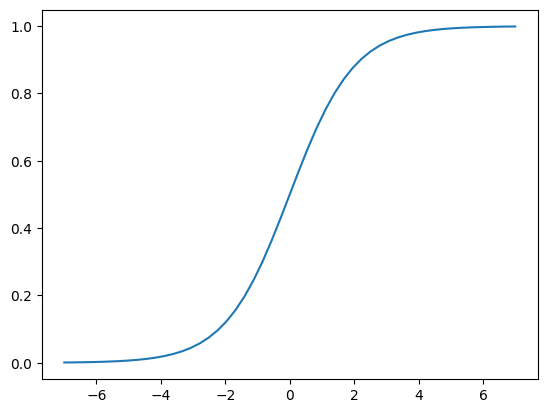

In [68]:
plt.plot(z, sigmoid(z))

In [70]:
def linear_regression(xi):
    result = w0
    
    for j in range(len(w)):
        result = result + xi[j] * w[j]
        
    return result

In [72]:
def logistic_regression(xi):
    score = w0
    
    for j in range(len(w)):
        score = score + xi[j] * w[j]
        
    result = sigmoid(score) # converting result to sigmoid for logistic regression
    return result

### 3.10 Training logistic regression with Scikit-Learn

* Train a model with Scikit-Learn
* Apply it to the validation dataset
* Calculate the accuracy

In [73]:
from sklearn.linear_model import LogisticRegression

In [74]:
model = LogisticRegression(solver='lbfgs')
# solver='lbfgs' is the default solver in newer version of sklearn
# for older versions, you need to specify it explicitly
model.fit(X_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [77]:
model.intercept_[0] # Bias term (w0)

np.float64(-0.1109287445794238)

In [78]:
model.coef_[0].round(3) # weights (w1, w2, w3 ..... wn)

array([ 0.564, -0.154, -0.519, -0.013, -0.095,  0.071, -0.098, -0.082,
       -0.033, -0.076, -0.354,  0.343, -0.098,  0.002, -0.251,  0.162,
       -0.02 ,  0.066, -0.098, -0.076,  0.251, -0.098, -0.261, -0.228,
        0.119, -0.121,  0.012, -0.095, -0.03 ,  0.045, -0.028,  0.162,
       -0.271,  0.221, -0.097, -0.098,  0.087, -0.05 , -0.098,  0.039,
        0.194, -0.098, -0.205, -0.072,  0.   ])

In [91]:
model.predict_proba(X_val)

array([[0.99213653, 0.00786347],
       [0.79007197, 0.20992803],
       [0.7762895 , 0.2237105 ],
       ...,
       [0.84985131, 0.15014869],
       [0.22331887, 0.77668113],
       [0.18964226, 0.81035774]], shape=(1409, 2))

In [92]:
y_pred = model.predict_proba(X_val)[:, 1]

In [93]:
y_pred

array([0.00786347, 0.20992803, 0.2237105 , ..., 0.15014869, 0.77668113,
       0.81035774], shape=(1409,))

#### Understanding `predict_proba` Output

When you run `model.predict_proba(X_val)`, each prediction looks like this: `[0.7, 0.3]`

1. **The First Value (Index 0)**:
   * **Significance**: Probability of the **Negative Class** (Class 0).
   * **In your case**: The probability that the customer **will NOT churn**.
   * *Example*: `0.7` means the model is 70% sure the customer is staying.

2. **The Second Value (Index 1)**:
   * **Significance**: Probability of the **Positive Class** (Class 1).
   * **In your case**: The probability that the customer **WILL churn**.
   * *Example*: `0.3` means the model thinks there is a 30% chance the customer leaves.

### Why do we use `[:, 1]`?
In your code, you likely used `y_pred = model.predict_proba(X_val)[:, 1]`. 
* This "slices" the array to keep **only the second column**.
* We do this because we are only interested in the **probability of Churning**. Since the two values always add up to **1.0 (100%)**, knowing the probability of Churning automatically tells us the probability of staying.

In [81]:
churn_decision = (y_pred >= 0.5)

In [82]:
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [83]:
(y_val == churn_decision).mean()

np.float64(0.801277501774308)

In [84]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [85]:
df_pred.head()

,probability,prediction,actual
0,0.007863,0,0
1,0.209928,0,0
2,0.223710,0,0
3,0.561123,1,1
4,0.219586,0,0


In [86]:
df_pred['correct'] = df_pred.prediction == df_pred.actual

In [87]:
df_pred.head()

,probability,prediction,actual,correct
0,0.007863,0,0,True
1,0.209928,0,0,True
2,0.223710,0,0,True
3,0.561123,1,1,True
4,0.219586,0,0,True


In [88]:
df_pred.correct.mean()

np.float64(0.801277501774308)

#### Model Evaluation: Accuracy

* **What it signifies**: The percentage of total predictions that your model got exactly right (both correctly predicting who stays AND who leaves).
* **How it's calculated**: 
    1. `df_pred['correct'] = df_pred.prediction == df_pred.actual`: This creates a Boolean column where `True` means the model was right and `False` means it was wrong.
    2. `.mean()`: In Python, `True` is treated as `1` and `False` as `0`. Taking the average of these 1s and 0s gives you the fraction of correct hits.

* **Notebook Example**: 
    If `df_pred.correct.mean()` returns **0.80**, it means your model is **80% accurate** on the validation data.

* **The Catch**: 
    While 80% sounds good, remember your **baseline** (the percentage of people who don't churn) was ~73%. Accuracy only tells part of the story—it doesn't tell you if you are missing "Churners" specifically.

In [89]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

### From Probability to Decision

1. **`predict_proba(X_val)`**:
   * **What it does**: Instead of a simple "Yes/No," it returns the **probability** for each class. 
   * **The Output**: A pair of numbers for each customer (e.g., `[0.7, 0.3]`). We take the second value (`0.3`) as the probability of **Churn**.

2. **`y_pred`**:
   * This variable stores those soft probabilities (e.g., `0.15`, `0.82`). It tells us how *confident* the model is that a customer will leave.

3. **`churn_decision = (y_pred >= 0.5)`**:
   * **The Threshold**: We apply a logical cut-off (usually **0.5**). 
   * **The Result**: Any customer with a probability of 50% or higher is flagged as `True` (Will Churn).

4. **The Effect**:
   * **Binary Classification**: This converts the model's "nuanced opinion" into a "hard action." 
   * **Business Impact**: This list of `True` values is what the marketing team uses to send out discount emails or retention offers.

### 3.11 Model interpretation

* Look at the coefficients
* Train a smaller model with fewer features

In [95]:
a = [1, 2, 3, 4]
b = 'abcd'

In [96]:
dict(zip(a, b))

{1: 'a', 2: 'b', 3: 'c', 4: 'd'}

In [99]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=Month-to-month': np.float64(0.564),
 'contract=One year': np.float64(-0.154),
 'contract=Two year': np.float64(-0.519),
 'dependents=No': np.float64(-0.013),
 'dependents=Yes': np.float64(-0.095),
 'deviceprotection=No': np.float64(0.071),
 'deviceprotection=No internet service': np.float64(-0.098),
 'deviceprotection=Yes': np.float64(-0.082),
 'gender=Female': np.float64(-0.033),
 'gender=Male': np.float64(-0.076),
 'internetservice=DSL': np.float64(-0.354),
 'internetservice=Fiber optic': np.float64(0.343),
 'internetservice=No': np.float64(-0.098),
 'monthlycharges': np.float64(0.002),
 'multiplelines=No': np.float64(-0.251),
 'multiplelines=No phone service': np.float64(0.162),
 'multiplelines=Yes': np.float64(-0.02),
 'onlinebackup=No': np.float64(0.066),
 'onlinebackup=No internet service': np.float64(-0.098),
 'onlinebackup=Yes': np.float64(-0.076),
 'onlinesecurity=No': np.float64(0.251),
 'onlinesecurity=No internet service': np.float64(-0.098),
 'onlinesecurity=Yes

In [100]:
small = ['contract', 'tenure', 'monthlycharges'] # lets take few features to understand

In [101]:
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'Two year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'Month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'Month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'Month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'Two year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'Month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'Month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'Month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'Two year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'Month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [102]:
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

In [106]:
dicts_train_small

[{'contract': 'Two year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'Month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'Month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'Month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'Two year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'Month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'Month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'Month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'Two year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'Month-to-month', 'tenure': 6, 'monthlycharges': 109.9},
 {'contract': 'Two year', 'tenure': 72, 'monthlycharges': 99.9},
 {'contract': 'Month-to-month', 'tenure': 17, 'monthlycharges': 102.55},
 {'contract': 'Two year', 'tenure': 66, 'monthlycharges': 58.2},
 {'contract': 'Month-to-month', 'tenure': 2, 'monthlycharges': 68.95},
 {'contract': 'Month-to-month', 't

In [103]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [104]:
dv_small.get_feature_names_out()

array(['contract=Month-to-month', 'contract=One year',
       'contract=Two year', 'monthlycharges', 'tenure'], dtype=object)

In [109]:
X_train_small = dv_small.transform(dicts_train_small)
X_train_small

array([[  0.  ,   0.  ,   1.  , 115.5 ,  72.  ],
       [  1.  ,   0.  ,   0.  ,  95.25,  10.  ],
       [  1.  ,   0.  ,   0.  ,  75.55,   5.  ],
       ...,
       [  1.  ,   0.  ,   0.  ,  90.  ,   2.  ],
       [  0.  ,   0.  ,   1.  ,  24.5 ,  27.  ],
       [  1.  ,   0.  ,   0.  ,  80.85,   9.  ]], shape=(4225, 5))

In [112]:
model_small = LogisticRegression(solver='lbfgs')
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [113]:
w0 = model_small.intercept_[0]
w0

np.float64(-2.477957595829565)

In [114]:
w = model_small.coef_[0]
w.round(3)

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [115]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=Month-to-month': np.float64(0.971),
 'contract=One year': np.float64(-0.024),
 'contract=Two year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

In [116]:
-2.47 + (-0.949) + 30 * 0.027 + 24 * (-0.036)

-3.473

In [117]:
sigmoid(_)

np.float64(0.030090303318277657)

### 3.12 Using the model

In [119]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

In [121]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train) # this is same as fit and transform

In [122]:
y_full_train = df_full_train.churn.values

In [123]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_full_train, y_full_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [124]:
dicts_test = df_test[categorical + numerical].to_dict(orient='records')

In [125]:
X_test = dv.transform(dicts_test)

In [126]:
y_pred = model.predict_proba(X_test)[:, 1]

In [128]:
churn_decision = (y_pred >= 0.5)

In [129]:
(churn_decision == y_test).mean()

np.float64(0.8140525195173882)

In [130]:
y_test

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [131]:
customer = dicts_test[-1]
customer

{'gender': 'Female',
 'seniorcitizen': 0,
 'partner': 'Yes',
 'dependents': 'Yes',
 'phoneservice': 'Yes',
 'multiplelines': 'Yes',
 'internetservice': 'Fiber optic',
 'onlinesecurity': 'Yes',
 'onlinebackup': 'No',
 'deviceprotection': 'Yes',
 'techsupport': 'No',
 'streamingtv': 'Yes',
 'streamingmovies': 'Yes',
 'contract': 'Month-to-month',
 'paperlessbilling': 'Yes',
 'paymentmethod': 'Electronic check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [132]:
X_small = dv.transform([customer])

In [133]:
model.predict_proba(X_small)[0, 1]

np.float64(0.6613470087309817)

In [134]:
y_test[-1]

np.int64(1)

### 3.13 Summary

* Feature importance - risk, mutual information, correlation
* One-hot encoding can be implemented with `DictVectorizer`
* Logistic regression - linear model like linear regression
* Output of log reg - probability
* Interpretation of weights is similar to linear regression


#### Other projects

* Lead scoring - https://www.kaggle.com/ashydv/leads-dataset
* Default prediction - https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients
